In [4]:
#read the data
import sqlite3
import pandas as pd
import glob
import os
DB_PATH = "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Arkansas Tech Social Media/social_media.db"
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM post", conn)
print(df.columns.tolist())

['Post ID', 'Account ID', 'Account username', 'Account name', 'Description', 'Duration (sec)', 'Publish time', 'Permalink', 'Post type', 'Data comment', 'Date', 'Views', 'Likes', 'Shares', 'Comments', 'Saves', 'Reach', 'Follows']


In [5]:
from textblob import TextBlob
df["Description"] = df["Description"].astype(str)
df["sentiment"] = df["Description"].apply(lambda x: TextBlob(x).sentiment.polarity)
df["subjectivity"] = df["Description"].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df["len_chars"] = df["Description"].apply(len)
df["len_words"] = df["Description"].apply(lambda x: len(x.split()))

In [6]:
df['Publish time'].head()

0    08/01/2024 09:08
1    10/31/2024 14:16
2    10/30/2024 10:00
3    10/29/2024 11:16
4    10/28/2024 09:11
Name: Publish time, dtype: object

In [7]:
df['Publish time'] = pd.to_datetime(df['Publish time'])
df['date']     = df['Publish time'].dt.date       # 2024-03-20 (date object)
df['hour']     = df['Publish time'].dt.hour       # 0-23
df['minute']   = df['Publish time'].dt.minute     # 0-59
df['weekday']  = df['Publish time'].dt.day_name() # "Monday"
df['month']    = df['Publish time'].dt.month      # 1-12
df['year']     = df['Publish time'].dt.year       # 2024

In [8]:
df.shape

(268, 28)

In [9]:
df['Post type'].unique()

array(['IG reel', 'IG carousel', 'IG image', None], dtype=object)

In [10]:
post_type = 'IG reel' # keep the "IG" add reel, carousel, image

new = df[df['Post type'] == post_type].copy()

In [11]:
new.shape

(128, 28)

C:\Users\tyler\AppData\Local\Temp\ipykernel_34568\713108357.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new = new.fillna(0)
C:\Users\tyler\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\tyler\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\tyler\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:14

Calinski–Harabasz Index for 2 clusters: 262.09012033162224
Calinski–Harabasz Index for 3 clusters: 287.4957213808686
Calinski–Harabasz Index for 4 clusters: 532.494825501974
Calinski–Harabasz Index for 5 clusters: 655.407427893406
Calinski–Harabasz Index for 6 clusters: 852.7808045103337
               Post ID         Account ID          Account username  \
0    17927394071816206  17841402627774708              atu_business   
1    17988368402736497  17841400588879469             _livjohnson34   
2    17864129277252817  17841402627774708              atu_business   
4    18057994513852516  17841402627774708              atu_business   
6    18240619846285920  17841468167257244  marketing_taylorsversion   
..                 ...                ...                       ...   
248  18473662024032918  17841400314558589    atuagriculture_tourism   
251  17983797275773060  17841402627774708              atu_business   
254  17971859732664306  17841400588879469             _livjohnson34   
2

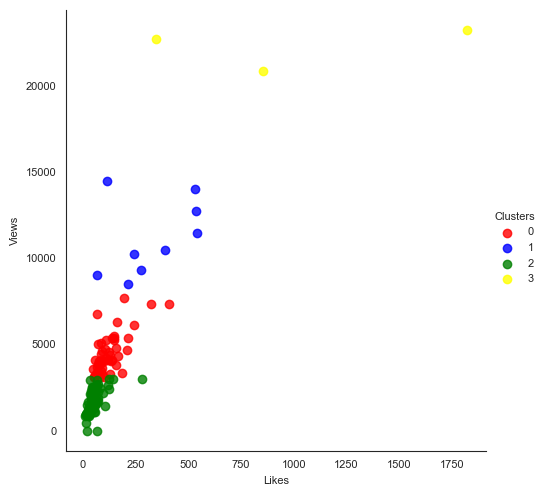

In [12]:
var1 = 'Likes'
var2 = 'Views'
Constant = 'Post type'

# Fix: convert to numeric, coercing any stray strings to NaN, then fill again
new[var1] = pd.to_numeric(new[var1], errors='coerce')
new[var2] = pd.to_numeric(new[var2], errors='coerce')
new = new.fillna(0)

# k-means
from sklearn.cluster import KMeans
tocluster=new[[var1,var2]]
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(tocluster)

#Apply CH to Different Numbers of Clusters:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
tocluster=new[[var1,var2]]
for i in range(2,7):
  kmeans = KMeans(n_clusters=i,random_state=42)
  kmeans.fit(tocluster)
  ch_score = calinski_harabasz_score(tocluster, kmeans.labels_)
  print("Calinski–Harabasz Index for",i,"clusters:", ch_score)
  
#Continuing with 5 clusters
from sklearn.cluster import KMeans
tocluster=new[[var1,var2]]
kmeans = KMeans(n_clusters=4,random_state=42)
kmeans.fit(tocluster)
clusters = kmeans.predict(tocluster)

#Look at cluster membership
new['cluster'] = clusters.tolist()
print(new)

#cluster summary
p1=new.pivot_table(index="cluster",values=[var1,var2],aggfunc="mean")
p2=new.pivot_table(index="cluster",values=[Constant],aggfunc="count")
print("Cluster Means /n",p1)
print("/n /n Number of, {Constant}, per Cluster /n",p2)

#plotting clusters
import seaborn as sns
import matplotlib.pyplot as plt
new["Clusters"]=clusters
#set font size of labels on matplotlib plots
plt.rc('font', size=8)
sns.set_style('white')
#set the colors used in the graph, see https://xkcd.com/color/rgb/
customPalette = ['red', 'blue', 'green', 'yellow', 'black' ]
sns.set_palette(customPalette)
#plot data with seaborn
facet = sns.lmplot(data=new, x=var1, y=var2, hue='Clusters',
fit_reg=False, legend=True)

In [13]:
# if cluster is 0 and 3 what is the average len_chars and len_words? 
result = new[new['cluster'].isin([0, 3])][['len_chars', 'len_words']].mean()
print(result)

len_chars    301.431373
len_words     43.313725
dtype: float64


In [14]:
print(new.columns.tolist())

['Post ID', 'Account ID', 'Account username', 'Account name', 'Description', 'Duration (sec)', 'Publish time', 'Permalink', 'Post type', 'Data comment', 'Date', 'Views', 'Likes', 'Shares', 'Comments', 'Saves', 'Reach', 'Follows', 'sentiment', 'subjectivity', 'len_chars', 'len_words', 'date', 'hour', 'minute', 'weekday', 'month', 'year', 'cluster', 'Clusters']


In [15]:
x0 = new[new['cluster'].isin([0, 3])][['sentiment', 'subjectivity']].mean()
print(x0)

sentiment       0.221044
subjectivity    0.335307
dtype: float64


In [16]:
x1 = new.groupby('cluster')[['sentiment','subjectivity']].mean()
print(x1)

         sentiment  subjectivity
cluster                         
0         0.222052      0.326461
1         0.123042      0.296481
2         0.215238      0.406514
3         0.204919      0.476852


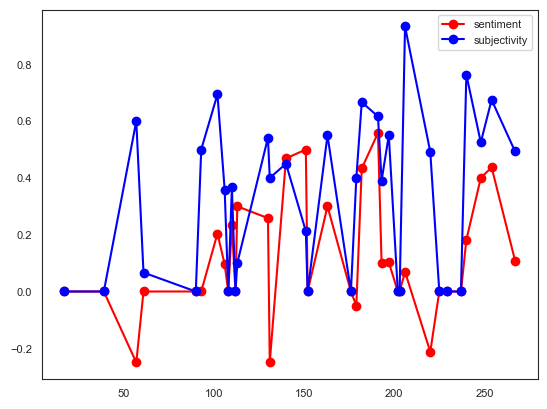

In [17]:
Likes_mean = new["Likes"].mean()
over_mean_likes = new[
    (new['Likes'] >= Likes_mean)
].copy()

ax = over_mean_likes[['sentiment', 'subjectivity']].plot(marker='o')

plt.show()

In [18]:
# run this by itself to run r
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


C:\Users\tyler\anaconda3\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "date". Fall back to string conversion. The error is: NaTType does not support toordinal
  warnings.warn('Error while trying to convert '



Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

In addition: Warning messages:
1: package 'ggplot2' was built under R version 4.5.2 
2: package 'scales' was built under R version 4.5.2 
3: package 'dplyr' was built under R version 4.5.2 


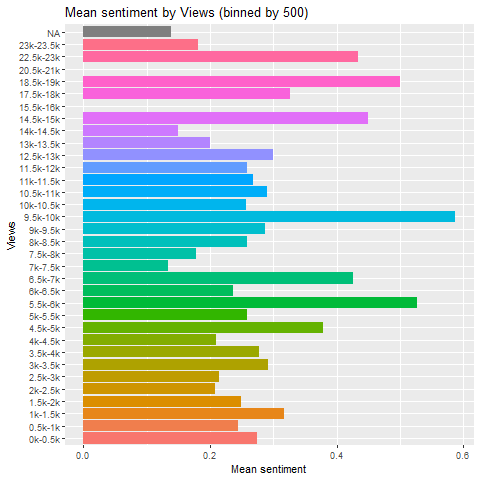

In [19]:
%%R -i df
options(scipen=999)
library(ggplot2)
library(scales)
library(dplyr)

df$Views <- as.numeric(df$Views)

breaks <- seq(0, max(df$Views, na.rm=TRUE) + 500, by=500)
labels <- paste0(head(breaks/1000, -1), "k-", (head(breaks/1000, -1) + 0.5), "k")

df$views_group <- cut(df$Views, breaks=breaks, labels=labels)

df_grouped <- df %>%
  group_by(views_group) %>%
  summarise(mean_sentiment = mean(sentiment, na.rm=TRUE))

ggplot(df_grouped, aes(x=views_group, y=mean_sentiment, fill=views_group)) + 
  geom_bar(stat="identity") +
  labs(title="Mean sentiment by Views (binned by 500)",
       x="Views",
       y="Mean sentiment") +
  coord_flip() +
  theme(legend.position="none")

In [20]:
df['date'] = df['date'].astype(str)

In [21]:
%%R -i df

dff <- df[df$`Post type` == 'IG reel', ]

dff$Views <- as.numeric(dff$Views)
cor(dff$Views, dff$subjectivity, use="complete.obs")# -0.07365929  more subjective post get slightly few views 
cor(dff$Views, dff$sentiment, use="complete.obs")# -0.07239641 MORE POS GET SLIGHTLY FEWER VIEWS

dff$Likes <- as.numeric(dff$Likes)
cor(dff$Likes, dff$sentiment, use="complete.obs")# -0.1459758 MORE POS SENT =FEWER LIKES
cor(dff$Likes, dff$subjectivity, use="complete.obs")# -0.05272143 NO RELATIONSHIP

dff$`Duration (sec)` <- as.numeric(dff$`Duration (sec)`)
cor(dff$`Duration (sec)`, dff$Likes, use="complete.obs")# -0.02849075 LONGER THE REEL LESS LIKES
cor(dff$`Duration (sec)`, dff$Views, use="complete.obs")# -0.06968806 LONGER REEL LESS VIEWS

[1] -0.06968806


In [27]:
#read the data
import sqlite3
import pandas as pd
import glob
import os
DB_PATH = "C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Arkansas Tech Social Media/social_media.db"
conn = sqlite3.connect(DB_PATH)
reels = pd.read_sql_query("""SELECT * FROM post WHERE "Post type" = 'IG reel'""", conn)
print(reels.columns.tolist())

# Force all engagement columns to numeric, coerce errors to NaN
engagement_cols = ["Duration (sec)", "Views", "Likes", "Shares",
                   "Comments", "Saves", "Reach", "Follows"]

reels[engagement_cols] = reels[engagement_cols].apply(pd.to_numeric, errors='coerce')

# Check — all should show float64 or int64
print(reels[engagement_cols].dtypes)

['Post ID', 'Account ID', 'Account username', 'Account name', 'Description', 'Duration (sec)', 'Publish time', 'Permalink', 'Post type', 'Data comment', 'Date', 'Views', 'Likes', 'Shares', 'Comments', 'Saves', 'Reach', 'Follows']
Duration (sec)    float64
Views             float64
Likes             float64
Shares            float64
Comments          float64
Saves             float64
Reach             float64
Follows           float64
dtype: object


'data.frame':	98 obs. of  8 variables:
 $ Duration..sec.: num  29 18 7 25 12 11 6 13 60 36 ...
 $ Views         : num  872 1078 1477 3937 2632 ...
 $ Likes         : num  11 58 19 89 119 41 40 31 56 57 ...
 $ Shares        : num  2 3 1 24 3 8 3 3 3 4 ...
 $ Comments      : num  0 0 0 41 3 0 0 0 3 2 ...
 $ Saves         : num  0 1 0 3 2 1 1 3 2 1 ...
 $ Reach         : num  504 647 879 2213 1370 ...
 $ Follows       : num  0 0 0 6 1 1 0 0 0 0 ...
 - attr(*, "na.action")= 'omit' Named int [1:30] 2 5 17 20 22 24 28 29 35 36 ...
  ..- attr(*, "names")= chr [1:30] "2" "5" "17" "20" ...
Parallel analysis suggests that the number of factors =  NA  and the number of components =  1 

Loadings:
               RC1    RC2   
Duration..sec.         0.491
Views           0.863       
Likes           0.964       
Shares          0.903       
Comments               0.874
Saves           0.887       
Reach           0.858       
Follows         0.600  0.666

                 RC1   RC2
SS loadings    4

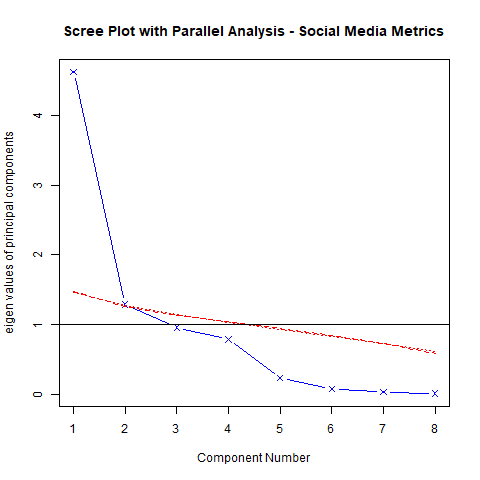

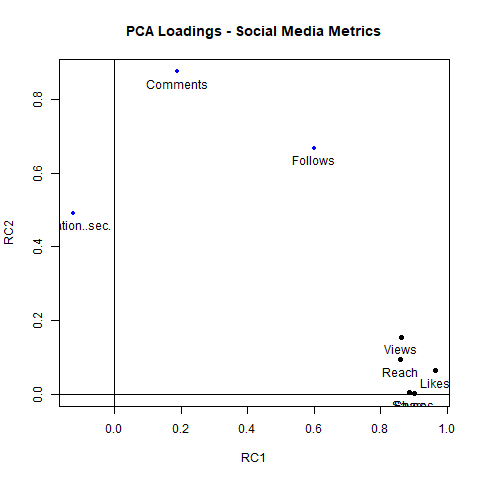

In [28]:
%%R -i reels
library(psych)

engagement_cols <- c("Duration (sec)", "Views", "Likes", "Shares",
                     "Comments", "Saves", "Reach", "Follows")

# ✅ Use 'reels' not 'df'
data_pca <- reels[, engagement_cols]

# ✅ Force numeric (safety net in case rpy2 passed them as character)
data_pca <- as.data.frame(lapply(data_pca, as.numeric))

# Remove rows with any missing values
data_pca <- na.omit(data_pca)

# Confirm all numeric before proceeding
str(data_pca)

# ── 3. Parallel analysis ──
set.seed(1234)
fa.parallel(data_pca, fa = "pc", n.iter = 100,
            show.legend = FALSE,
            main = "Scree Plot with Parallel Analysis - Social Media Metrics")
abline(h = 1)

# ── 4. PCA without rotation ──
PC <- principal(data_pca, nfactors = 2, rotate = "none")
PC

# ── 5. PCA with varimax rotation ──
rc <- principal(data_pca, nfactors = 2, rotate = "varimax")
rc

# ── 6. Loadings > |0.4| ──
print(rc$loadings, cutoff = 0.4)

# ── 7. Component scores ──
rc_scores <- principal(data_pca, nfactors = 2, rotate = "varimax", scores = TRUE)
head(rc_scores$scores)

# ── 8. Scoring coefficients ──
round(unclass(rc_scores$weights), 2)

# ── 9. Biplot ──
factor.plot(rc, labels = colnames(data_pca),
            main = "PCA Loadings - Social Media Metrics")

# ── 10. Correlation with scores ──
cor(data_pca, rc_scores$scores)